# Sucrose Shock Analysis

Status: cleaned for the publication supplement. Supported cells start from the curated time-series data committed under `data/time-series/` and write generated files under `outputs/` directories.

Upstream image/video processing, raw acquisition data, segmentation outputs, bead-center detection outputs, and other large intermediates are intentionally not included in this repository. Cells from the original notebook that depended on those local upstream files have been replaced by archived notes.


### 📦 Importing Required Libraries

This cell imports all the necessary Python libraries for data analysis and plotting:

- `numpy`, `pandas` for data handling  
- `matplotlib.pyplot`, `seaborn` for plotting and visualization  
- `os`, `pathlib.Path` for file handling  
- `scipy` libraries for signal processing and curve fitting  
- `sklearn.metrics.r2_score` for computing the R² value  
- `%matplotlib inline` ensures that plots display directly in the notebook


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import scipy
from scipy.optimize import curve_fit
import scipy.signal
import re
from scipy.interpolate import interp1d
import scipy.signal as signal
from sklearn.metrics import r2_score

import sys
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "bead_time_series.py").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
else:
    sys.path.insert(0, str((NOTEBOOK_DIR / "code" / "bead-assay").resolve()))
from bead_time_series import ROOT, legacy_speed_tree, legacy_condition_folder, read_legacy_speed_csv, iter_condition_traces, median_kernel_size

# Ensure plots are rendered in the notebook
%matplotlib inline

## Defining terms for the exponential function 


In [2]:
dict_for_plotting = {}
for name in ['0', '100', '200', '300', '400', '500']:
    dict_for_plotting[name] = []

In [3]:
# Define exponential functions
def old_exp_decrease(t, A, tau, C, t0):
    return A / (1 + np.exp((t-175-t0) / tau)) + C

def exp_decrease(t, tau, t0):
    global speed_initial
    global speed_final
    return (speed_initial-speed_final) / (1 + np.exp((t-175-t0) / tau)) + speed_final

def exp_increase(t, tau, t0):
    global speed_increase_max
    global speed_increase_min
    return speed_increase_min + (speed_increase_max  - speed_increase_min)/ (1 + np.exp(-(t-270-t0) / tau))

def old_exp_increase(t, B, tau, D, t0):
    return B * (1 - np.exp(-(t - t0) / tau)) + D

def exponential_decay(t, tau, t0):
    global speed_initial
    global speed_final
    return np.where(t < t0, speed_initial, (speed_initial-speed_final) * np.exp(-(t - t0) / tau) + speed_final)

def calculate_time_constants(time, speed, filename, sucrose_choice):
    results = []

    #normalize speed for ease of fitting
    speed = speed / np.average(speed[time<=180]) #normally 300

    # Filter data for decrease and increase
    mask_decrease = (time >= 175) & (time <= 240)
    time_decrease = time[mask_decrease]
    speed_decrease = speed[mask_decrease]

    mask_increase = (time > 250) & (time <= 360)
    time_increase = time[mask_increase]
    speed_increase = speed[mask_increase]
   
    global speed_initial
    global speed_final
    speed_initial = np.average(speed[(time >= 155) & (time <= 175)])
    speed_final = np.average(speed[(time >= 215) & (time <= 235)])

    global speed_increase_max
    global speed_increase_min
    speed_increase_min = np.average(speed[(time >= 240) & (time <= 260)])
    speed_increase_max = np.average(speed[(time >= 330) & (time <= 350)])


    global dict_for_plotting
    dict_for_plotting[filename].append(speed[(time >= 155) & (time <= 175)])
    dict_for_plotting['0'].append(speed[(time >= 215) & (time <= 235)])

    #Fit the decrease segment
    try:
        popt_decrease, _ = curve_fit(
            exp_decrease,
            time_decrease,
            speed_decrease,
            p0=[10, 10],
            bounds=(0, np.inf)
        )
        A_dec, C_dec = speed_initial-speed_final, speed_final
        tau_dec, t0_dec = popt_decrease
    except Exception as e:
        print(f"Error fitting decrease for {filename}: {e}")
        tau_dec = np.nan
        A_dec, tau_dec, C_dec, t0_dec = [np.nan, np.nan, np.nan, np.nan]
        popt_decrease = [np.nan, np.nan, np.nan, np.nan]

    if True: #plotting to double check
        if filename == "500": #filename[-13:-10]
            #print('here')
            plt.plot(time, speed)
            plt.plot(time_decrease, exp_decrease(time_decrease, *popt_decrease))


    # Fit the increase segment
    try:
        popt_increase, _ = curve_fit(
            exp_increase, time_increase, speed_increase, p0=[3, -10]
        )
        tau_inc, t0_inc = popt_increase
    except Exception as e:
        print(f"Error fitting increase for {filename}: {e}")
        tau_inc = np.nan
        popt_increase = [np.nan, np.nan]

    if True:
        if filename == "500":
            plt.plot(time_increase, exp_increase(time_increase, *popt_increase))

    # Save results for this concentration
    condition = filename.split(".csv")[
        0
    ]  # Assuming the filename contains the concentration info
    results.append(
        {
            "Condition": condition,
            "Tau (Decrease)": tau_dec,
            "Tau (Increase)": tau_inc,
            "Time Range (Decrease)": f"180-270",
            "Time Range (Increase)": f"270-{time[-1]}",
        }
    )

    return tau_dec, t0_dec, A_dec, tau_inc

### Data Processing Functions

This section defines three functions used to process time-series data by interpolating to a fixed frame rate and binning into defined intervals:


In [4]:
def convert_to_300fps(time_stamps, data, target_fps=300):# Calculate the total duration
    total_time = time_stamps[-1]
    
    # Generate new time stamps at the target FPS
    new_time_stamps = np.linspace(0, total_time, int(total_time * target_fps))
    
    # Create a linear interpolator
    interpolator = interp1d(time_stamps, data, kind='linear', fill_value='extrapolate')
    
    # Interpolate data to the new time stamps
    interpolated_data = interpolator(new_time_stamps)
    
    return new_time_stamps[:380*target_fps], interpolated_data[:380*target_fps]

def bin_data(time_stamps, data, bin_size=0.1):
    data = data[time_stamps < 380]
    time_stamps = time_stamps[time_stamps < 380]
    
    # Determine the range of time stamps
    start_time = 0
    end_time = 380
    
    # Create bin edges
    bin_edges = np.arange(start_time, end_time + bin_size, bin_size)
    
    # Calculate bin indices for each time stamp
    bin_indices = np.digitize(time_stamps, bin_edges, right=False) - 1  # Bin indices (0-based)

    # Initialize lists to store results
    binned_times = np.arange(0,end_time,0.1)
    averaged_data = np.zeros_like(binned_times)
    
    # Iterate over each bin
    for i in range(len(bin_edges) - 1):
        # Get indices of data points in the current bin
        indices_in_bin = np.where(bin_indices == i)[0]
        
        if len(indices_in_bin) > 0:
            # Calculate the midpoint of the current bin
            bin_midpoint = (bin_edges[i] + bin_edges[i + 1]) / 2
            binned_times[i] = (bin_midpoint)
            
            # Calculate the average of data points in the current bin
            average_value = np.mean(data[indices_in_bin])
            averaged_data[i] = (average_value)
    
    return np.array(binned_times), np.array(averaged_data)

def bin_data_2(time_stamps, data, bin_size=0.1):
    T = time_stamps[time_stamps<=380]
    F = data[time_stamps<=380]
    
    # Resample into 4000 bins
    data_F = np.zeros(3800)
    data_T = np.zeros(3800)

    bin = 0
    counter = 0

    for kk in range(len(T)):
        counter += 1
        pos = int(T[kk] // 0.1)
        if pos < 3800:
            data_F[pos] += F[kk]
            if T[kk] // 0.1 > bin + 1:
                data_F[pos - 1] /= counter
                data_T[pos - 1] = (bin + 0.5) * 0.1
                counter = 0
                bin += 1
        else:
            data_F[pos - 1] /= counter
            data_T[pos - 1] = (bin + 0.5) * 0.1
            break
    
    return data_T, data_F

## Sucrose 
Extracing motor speeds from the sucrose results folder 


<ipython-input-1-2c392d7d7f7b>:13: RuntimeWarning: overflow encountered in exp
  return speed_increase_min + (speed_increase_max  - speed_increase_min)/ (1 + np.exp(-(t-270-t0) / tau))


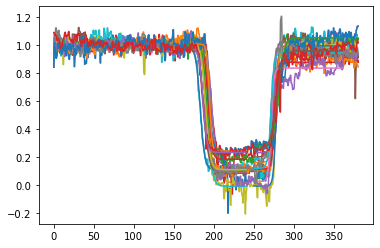

In [5]:
parentDir = legacy_speed_tree(assay="Sucrose")
outputDir = ROOT / "outputs" / "bead" / "sucrose-shock"
os.makedirs(outputDir, exist_ok=True)

sucrose_choice = True
time_mult = 10

# Initialize the list to store time, data, and sucrose concentrations
all_time = []
all_data = []
concentrations = []

tau_values = {}
t0_values = {}
A_values = {}
tau_inc_values = {}

for concentration in [200, 300, 400, 500]:
    condition_dir = Path(parentDir) / f"{concentration}mM"
    csv_files = sorted(condition_dir.glob("*.csv"))
    if not csv_files:
        print(f"No traces found for {concentration} mM in {condition_dir}")
        continue

    tau_values[str(concentration)] = []
    t0_values[str(concentration)] = []
    A_values[str(concentration)] = []
    tau_inc_values[str(concentration)] = []
    condition_cells = []

    for file_path in csv_files:
        if concentration == 200 and "cell4" in file_path.stem:
            continue

        trace = read_legacy_speed_csv(file_path)
        time = trace["frame"].to_numpy() / 300
        data = trace["frequency_hz"].to_numpy()
        if len(data) == 0:
            continue
        if data[0] < 0:
            data = data * -1

        data = signal.medfilt(data, kernel_size=median_kernel_size(time, window_s=1.0))
        new_time, interp_data = bin_data(time, data)

        tau_dec, t0_dec, A_dec, tau_inc = calculate_time_constants(new_time, interp_data, str(concentration), sucrose_choice)
        if ((tau_dec > 0) & (tau_dec < 40)):
            tau_values[str(concentration)] += [float(tau_dec)]
            t0_values[str(concentration)] += [float(t0_dec)]
            A_values[str(concentration)] += [float(A_dec)]
            tau_inc_values[str(concentration)] += [float(tau_inc)]

        condition_cells.append(interp_data)

    if not condition_cells:
        continue

    allcells = np.asarray(condition_cells)
    data_mean = np.average(allcells, axis=0)
    data_mean_norm = data_mean / np.average(data_mean[:180 * time_mult])
    data_std = np.std(allcells, axis=0) / np.average(data_mean[:180 * time_mult])
    upper = data_mean_norm + 0.5 * data_std
    lower = data_mean_norm - 0.5 * data_std

    time = new_time
    all_time.append(time)
    all_data.append(data_mean_norm)
    concentrations.append(float(concentration))

    df_output = pd.DataFrame({
        'Time': time,
        'Normalized Data': data_mean_norm
    })
    output_file = outputDir / f"normalized_data_{concentration}mM.csv"
    # df_output.to_csv(output_file, index=False)

# Sort the concentrations and associated data
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]

In [6]:
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]

print("Sorted concentrations:", sorted_concentrations)

# Save a code-generated panel corresponding to the sucrose motor-speed panel.
figure_dir = ROOT / "outputs" / "figure-panels"
figure_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'font.size': 25, 'font.family': 'Arial'})
fig, ax = plt.subplots(figsize=(10, 5.5))
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)
ax.tick_params(axis='x', direction='in', width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', width=2, length=7.5, pad=8)

for time_arr, mean_arr, conc in zip(sorted_times, sorted_data, sorted_concentrations):
    ax.plot(time_arr, mean_arr, label=f'{int(conc)} mM')

ax.axvspan(180, 270, color='lightgray', alpha=0.6)
ax.set_xlabel('Time (s)', fontsize=25)
ax.set_ylabel('Rotation Speed (Normalized)', fontsize=25)
ax.set_xlim(0, 380)
ax.set_ylim(0, 1.25)
ax.set_xticks(np.arange(0, 381, 50))
ticks = np.arange(0, 1.26, 0.25)
ax.set_yticks(ticks[:-1])
ax.legend(loc='lower left', fontsize=25, frameon=False)
fig.tight_layout()
fig.savefig(figure_dir / "figure-1d-sucrose-motor-speed.pdf", dpi=350, bbox_inches='tight')
plt.close(fig)


Sorted concentrations: [200.0, 300.0, 400.0, 500.0]


In [7]:
def equalize_lists(data):
    if not data:
        return {}

    lengths = [len(v) for v in data.values()]
    if max(lengths) == 0:
        return {k: [] for k in data}

    max_length = max(lengths)
    return {
        k: v + [np.nan] * (max_length - len(v))
        for k, v in data.items()
    }

In [8]:
# Save per-cell fit parameters to intermediate CSVs in the output directory.
# Downstream cells (tau/magnitude vs osmolarity) read from these files.
new_tau_values    = equalize_lists(tau_values)
new_tau_inc_values = equalize_lists(tau_inc_values)
new_t0_values     = equalize_lists(t0_values)
new_A_values      = equalize_lists(A_values)

csv_dir = outputDir
pd.DataFrame(new_tau_values).to_csv(    csv_dir / "sucrose_tau_values.csv")
pd.DataFrame(new_tau_inc_values).to_csv(csv_dir / "sucrose_tau_inc_values.csv")
pd.DataFrame(new_t0_values).to_csv(     csv_dir / "sucrose_t0_values.csv")
pd.DataFrame(new_A_values).to_csv(      csv_dir / "sucrose_A_values.csv")

print("tau_values   :", tau_values)
print("tau_inc_values:", tau_inc_values)
print("t0_values    :", t0_values)
print("A_values     :", A_values)


tau_values   : {'200': [1.7608862944117427, 1.319260598268189, 3.85737313753509, 4.056284023169738, 3.5464659005284482, 4.684942920795857, 4.2280826118968236], '300': [3.6672873309151575, 3.8034552008708293, 4.593412426264375, 5.260558074873389, 4.47422871801063, 4.410090439633192, 3.756200288667649, 4.912307841396248, 2.742088390956119, 3.4313577359628398], '400': [3.5980333187172433, 3.3646457696788326, 5.350606810528762, 3.7858621204785976, 4.672957136823708, 4.85015539579068, 3.956790346468741, 3.673650128248193], '500': [4.574276004001853, 2.852753624986292, 1.5845789305291218, 2.696624541819122, 2.372318383090033, 2.388635282523559, 3.165573579993995, 2.8135314920525247, 3.317818733331764, 2.812068632339944, 1.5500159227835735, 2.4424197655976223]}
tau_inc_values: {'200': [3.8965581238843643, 4.798143786104635, 2.34009867291228, 2.9716215990531354, 3.61899433865347, 2.6554783629263263, 1.6183869497364007], '300': [1.8633879112129856, 2.614759344212029, 1.9116401592641028, 3.37113

In [9]:
# Figure 1C – example single-motor trace (cell3, 500 mM sucrose) with inset
# showing the normalised speed and the sigmoidal fit.
# Corresponds to manuscript figure panel sucrose.pdf / Fig. 1C.

# --- load the example trace ---------------------------------------------------
example_row = None
example_trace = None
for row, trace in iter_condition_traces(assay="Sucrose", condition_mM=500):
    if row["cell_id"] == "cell3":
        example_row  = row
        example_trace = trace
        break

time_raw = example_trace["time_s"].to_numpy()
freq_raw = example_trace["frequency_hz"].to_numpy()

# --- plot settings ------------------------------------------------------------
plt.rcParams.update({"font.size": 25, "font.family": "Arial"})
fig, ax = plt.subplots(figsize=(10, 5.5))
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(2)
ax.tick_params(axis="x", direction="in", labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis="y", direction="in", labelsize=25, width=2, length=7.5, pad=8)

# main trace (already mean-binned at 0.1 s in the parquet)
ax.plot(time_raw, freq_raw)
ax.set_xlabel("Time (s)", fontsize=25)
ax.set_ylabel("Rotation Speed (Hz)", fontsize=25)
ax.set_xticks(np.arange(0, 381, 50))
ax.set_xlim(0, 370)
ax.set_yticks(np.arange(0, 70, 10))
ax.set_ylim(0, 70)
ax.axvspan(180, 270, color="lightgray", alpha=0.6)

# --- inset: normalised + filtered + fitted -----------------------------------
inset_ax = plt.axes([0.19, 0.20, 0.29, 0.45])

data_filt = signal.medfilt(freq_raw, kernel_size=median_kernel_size(time_raw, window_s=1.0))
time_b, data_b = bin_data(time_raw, data_filt)
data_norm = data_b / np.average(data_b[time_b <= 180])

inset_ax.plot(time_b, data_norm, alpha=0.6)

mask_dec = (time_b >= 175) & (time_b <= 240)
time_dec = time_b[mask_dec]
speed_dec = data_norm[mask_dec]

global speed_initial, speed_final
speed_initial = np.average(data_norm[(time_b >= 155) & (time_b <= 175)])
speed_final   = np.average(data_norm[(time_b >= 215) & (time_b <= 235)])

popt_dec, _ = curve_fit(exp_decrease, time_dec, speed_dec, p0=[10, 10], bounds=(0, np.inf))
tau_ex, t0_ex = popt_dec

inset_ax.plot(time_dec, exp_decrease(time_dec, *popt_dec),
              "--", color="black", linewidth=2.25, label="Fit")

# magnitude annotation (red vertical error bar)
x_mag      = 170
y_mag_top  = 1.05
y_mag_bot  = float(np.min(data_norm[(time_b >= 215) & (time_b <= 235)]))
y_mag_mid  = (y_mag_top + y_mag_bot) / 2
inset_ax.errorbar([x_mag], [y_mag_mid],
                  yerr=[(y_mag_top - y_mag_bot) / 2],
                  marker="None", linestyle="None",
                  ecolor="red", capsize=4, elinewidth=1.75, capthick=1.75)
inset_ax.text(x_mag - 3, y_mag_mid, "Magnitude",
              ha="right", va="center", rotation=90, fontsize=25)

# timescale annotation (purple horizontal error bar)
x_inflect = 175 + t0_ex
inset_ax.errorbar([x_inflect], [0.05], xerr=[6],
                  marker="None", linestyle="None",
                  ecolor="purple", capsize=4, elinewidth=1.75, capthick=1.75)
inset_ax.text(x_inflect, 0.07, "Time", ha="center", va="bottom", fontsize=25)

inset_ax.set_xlim(155, 245)
inset_ax.set_ylim(-0.05, 1.15)
inset_ax.axvspan(180, 270, color="lightgray", alpha=0.6)
inset_ax.tick_params(which="both", direction="in")
inset_ax.set_xticks([160, 200, 240])
inset_ax.set_yticks([0, 0.5, 1.0])

figure_dir = ROOT / "outputs" / "figure-panels"
fig.savefig(figure_dir / "figure-1c-sucrose-example-trace.pdf", dpi=350, bbox_inches="tight")
plt.close(fig)
print("Saved figure-1c-sucrose-example-trace.pdf")


Saved figure-1c-sucrose-example-trace.pdf


In [10]:
# Supplemental example trace – cell2 at 200 mM sucrose.
# Single-cell quality check; matches the style used in the supplemental
# individual-cells figure (sucros_individual-cells_all.pdf).

for row, trace in iter_condition_traces(assay="Sucrose", condition_mM=200):
    if row["cell_id"] == "cell2":
        ex200_trace = trace
        break

plt.rcParams.update({"font.size": 50, "font.family": "Arial"})
fig, ax = plt.subplots(figsize=(20, 10))
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(10)
ax.tick_params(axis="x", direction="in", labelsize=150, width=10, length=50, pad=8)
ax.tick_params(axis="y", direction="in", labelsize=150, width=10, length=50, pad=8)

ax.plot(ex200_trace["time_s"], ex200_trace["frequency_hz"], linewidth=6, color="blue")
ax.set_xticks(np.arange(0, 381, 150))
ax.set_xlim(0, 380)
ax.set_yticks(np.arange(0, 90, 40))
ax.set_ylim(0, 80)
ax.axvspan(180, 270, color="lightgray", alpha=0.6)

figure_dir = ROOT / "outputs" / "figure-panels"
fig.savefig(figure_dir / "supplement-sucrose-example-cell-200mM.pdf", dpi=350, bbox_inches="tight")
plt.close(fig)
print("Saved supplement-sucrose-example-cell-200mM.pdf")


Saved supplement-sucrose-example-cell-200mM.pdf


In [11]:
# Supplemental Figure – Viscosity-sucrose.pdf
# 4 panels (A–D): per-concentration population-averaged normalised speed
# with a dashed black line marking the estimated viscosity-driven speed reduction.

viscosity_reduction = {200: 0.18, 300: 0.26, 400: 0.36, 500: 0.43}

plt.rcParams.update({"font.size": 25, "font.family": "Arial"})
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5), sharey=True)

for ax, (time_arr, mean_arr, conc) in zip(axes, zip(sorted_times, sorted_data, sorted_concentrations)):
    conc_i = int(conc)
    ax.plot(time_arr, mean_arr, linewidth=2)

    # dashed viscosity line: flat at (1 - reduction) during shock; 1.0 elsewhere
    visc_red = viscosity_reduction[conc_i]
    visc_level = 1.0 - visc_red
    t = np.asarray(time_arr)
    visc_line = np.where((t >= 180) & (t <= 270), visc_level, 1.0)
    ax.plot(t, visc_line, "--", color="black", linewidth=2)

    ax.axvspan(180, 270, color="lightgray", alpha=0.6)
    ax.set_xlim(0, 380)
    ax.set_ylim(0, 1.4)
    ax.set_xticks(np.arange(0, 381, 150))
    ax.set_xlabel("Time (s)", fontsize=25)
    ax.set_title(f"{conc_i} mM", fontsize=25)
    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_linewidth(2)
    ax.tick_params(direction="in", width=2, length=7.5)

axes[0].set_ylabel("Rotation Speed (Normalised)", fontsize=25)
fig.tight_layout()

figure_dir = ROOT / "outputs" / "figure-panels"
fig.savefig(figure_dir / "supplement-sucrose-viscosity.pdf", dpi=350, bbox_inches="tight")
plt.close(fig)
print("Saved supplement-sucrose-viscosity.pdf")


Saved supplement-sucrose-viscosity.pdf


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Global plot settings
# -------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 25})

# -------------------------------
# Paths
# -------------------------------
save_root = ROOT / "outputs" / "bead" / "sucrose-individual-cells"
os.makedirs(save_root, exist_ok=True)

# -------------------------------
# Loop through compact canonical traces
# -------------------------------
for row, trace in iter_condition_traces(assay="Sucrose"):
    fig, ax = plt.subplots(figsize=(20, 10))

    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(10)

    ax.tick_params(axis='x', direction='in', labelsize=150, width=10, length=50, pad=8)
    ax.tick_params(axis='y', direction='in', labelsize=150, width=10, length=50, pad=8)

    ax.plot(trace["time_s"], trace["frequency_hz"], linewidth=6, color="blue")

    ax.set_xticks(np.arange(0, 381, 150))
    ax.set_xlim(0, 380)
    ax.set_yticks(np.arange(0, 90, 40))
    ax.set_ylim(0, 80)
    ax.axvspan(180, 270, color="lightgray", alpha=0.6)

    save_path = save_root / f"{row['condition_mM']}mM_{row['cell_id']}.pdf"
    plt.savefig(save_path, dpi=350)
    plt.close(fig)
    print(f"Saved figure: {save_path}")

Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell1.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell2.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell3.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell4.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell5.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell6.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell7.pdf

In [13]:
# Supplemental Figure – tau decrease vs. change in osmolarity
# (Panel A of sucros-time-charc.pdf / sfig:tau-sucro-increa-decrease).

import openpyxl  # noqa: F401  (ensure available; pandas uses it)

osmo_excel = ROOT / "data" / "Osmolarity-readings" / "sucrose-old.xlsx"
df_osmo = pd.read_excel(osmo_excel)
df_osmo.columns = df_osmo.columns.str.strip().str.lower()
osmotic_shock_values = df_osmo["change_in_osmolarity"].iloc[1:].values  # skip baseline row
concentrations_ordered = [200, 300, 400, 500]

tau_means, tau_stds = [], []
for c in concentrations_ordered:
    vals = [v for v in tau_values[str(c)] if not np.isnan(v)]
    tau_means.append(np.mean(vals))
    tau_stds.append(np.std(vals))

plt.rcParams.update({"font.size": 30, "font.family": "Arial"})
fig, ax = plt.subplots(figsize=(10, 5.5))
for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(2)
ax.tick_params(axis="x", direction="in", labelsize=30, width=2, length=7.5, pad=8)
ax.tick_params(axis="y", direction="in", labelsize=30, width=2, length=7.5, pad=8)

ax.errorbar(osmotic_shock_values, tau_means, yerr=tau_stds,
            marker="o", markeredgecolor="k", markersize=12,
            linestyle="None", color="black", ecolor="black", capsize=4)
ax.set_xticks(osmotic_shock_values)
ax.set_xlabel("Change in osmolarity (mOsmol/Kg)")
ax.set_ylabel("Characteristic Time (s)")
ax.set_xlim(80, 796.5)
ax.set_ylim(-0.5, 6.5)
ax.set_yticks([0, 1, 2, 3, 4, 5, 6])

figure_dir = ROOT / "outputs" / "figure-panels"
fig.savefig(figure_dir / "supplement-sucrose-tau-decrease.pdf", dpi=350, bbox_inches="tight")
plt.close(fig)
print("Saved supplement-sucrose-tau-decrease.pdf")


Saved supplement-sucrose-tau-decrease.pdf


In [14]:
# Supplemental Figure – tau increase (recovery) vs. change in osmolarity
# (Panel B of sucros-time-charc.pdf / sfig:tau-sucro-increa-decrease).

osmo_excel = ROOT / "data" / "Osmolarity-readings" / "sucrose-old.xlsx"
df_osmo = pd.read_excel(osmo_excel)
df_osmo.columns = df_osmo.columns.str.strip().str.lower()
osmotic_shock_values = df_osmo["change_in_osmolarity"].iloc[1:].values
concentrations_ordered = [200, 300, 400, 500]

tinc_means, tinc_stds = [], []
for c in concentrations_ordered:
    vals = [v for v in tau_inc_values[str(c)] if not np.isnan(v)]
    tinc_means.append(np.mean(vals))
    tinc_stds.append(np.std(vals))

plt.rcParams.update({"font.size": 30, "font.family": "Arial"})
fig, ax = plt.subplots(figsize=(10, 5.5))
for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(2)
ax.tick_params(axis="x", direction="in", labelsize=30, width=2, length=7.5, pad=8)
ax.tick_params(axis="y", direction="in", labelsize=30, width=2, length=7.5, pad=8)

ax.errorbar(osmotic_shock_values, tinc_means, yerr=tinc_stds,
            marker="o", markeredgecolor="k", markersize=12,
            linestyle="None", color="black", ecolor="black", capsize=4)
ax.set_xticks(osmotic_shock_values)
ax.set_xlabel("Change in osmolarity (mOsmol/Kg)")
ax.set_ylabel("Characteristic Time (s)")
ax.set_xlim(185, 796.5)
ax.set_ylim(-0.5, 6.5)
ax.set_yticks([0, 1, 2, 3, 4, 5, 6])

figure_dir = ROOT / "outputs" / "figure-panels"
fig.savefig(figure_dir / "supplement-sucrose-tau-increase.pdf", dpi=350, bbox_inches="tight")
plt.close(fig)
print("Saved supplement-sucrose-tau-increase.pdf")


Saved supplement-sucrose-tau-increase.pdf


In [15]:
# Figure 1E - normalised speed reduction vs. change in osmolarity.
# Red circles: total speed decrease (mean ± SD).
# Green triangles + dashed green line: estimated viscosity-driven reduction.
# Corresponds to manuscript panel sucrose.pdf / Fig. 1E.

from scipy.stats import linregress

osmo_excel = ROOT / "data" / "Osmolarity-readings" / "sucrose-old.xlsx"
df_osmo = pd.read_excel(osmo_excel)
df_osmo.columns = df_osmo.columns.str.strip().str.lower()
osmotic_shock_values = df_osmo["change_in_osmolarity"].iloc[1:].values
concentrations_ordered = [200, 300, 400, 500]

A_means, A_stds = [], []
for c in concentrations_ordered:
    vals = [v for v in A_values[str(c)] if not np.isnan(v)]
    A_means.append(np.mean(vals))
    A_stds.append(np.std(vals))

viscosity_dict = {200: 0.18, 300: 0.26, 400: 0.36, 500: 0.43}
viscosities = [viscosity_dict[c] for c in concentrations_ordered]

plt.rcParams.update({"font.size": 25, "font.family": "Arial"})
fig, ax = plt.subplots(figsize=(10, 5.5))
for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(2)
ax.tick_params(axis="x", direction="in", labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis="y", direction="in", labelsize=25, width=2, length=7.5, pad=8)

x_data = np.array(osmotic_shock_values)

# total speed decrease
ax.errorbar(x_data, A_means, yerr=A_stds,
            marker="o", markeredgecolor="k", markersize=12,
            linestyle="None", color="red", ecolor="black", capsize=4)

slope, intercept, *_ = linregress(x_data, A_means)
x_fit = np.linspace(x_data.min(), x_data.max(), 1000)
ax.plot(x_fit, slope * x_fit + intercept, "--", color="black", linewidth=3,
        label="Total speed decrease")

# viscosity estimate
ax.errorbar(x_data, viscosities,
            marker="^", markeredgecolor="green", markersize=12,
            linestyle="None", color="green", ecolor="green", capsize=4)
slope_v, intercept_v, *_ = linregress(x_data, viscosities)
ax.plot(x_fit, slope_v * x_fit + intercept_v, "--", color="green", linewidth=3,
        label="Speed decrease due to\nchange in viscosity")

ax.set_xticks(x_data)
ax.set_xlabel("Change in osmolarity (mOsmol/Kg)")
ax.set_ylabel("Speed Decrease (Normalised)")
ax.set_xlim(185, 796.5)
ax.set_ylim(-0.05, 1.15)
ax.legend(loc="upper left", frameon=False)

figure_dir = ROOT / "outputs" / "figure-panels"
fig.savefig(figure_dir / "figure-1e-sucrose-speed-decrease.pdf", dpi=350, bbox_inches="tight")
plt.close(fig)
print("Saved figure-1e-sucrose-speed-decrease.pdf")

# save stats
diff_values = np.array(A_means) - np.array(viscosities)
slope_d, intercept_d, r_d, p_d, err_d = linregress(x_data, diff_values)
stats_path = outputDir / "sucrose_A_linear_fit_stats.txt"
with open(stats_path, "w", encoding="utf-8") as f:
    f.write("Linear Fit -- Speed Decrease\n====================\n")
    f.write(f"Slope: {slope:.6f}\nIntercept: {intercept:.6f}\n\n")
    f.write("Linear Fit -- Viscosity\n====================\n")
    f.write(f"Slope: {slope_v:.6f}\nIntercept: {intercept_v:.6f}\n\n")
    f.write("Linear Fit -- Difference (Speed - Viscosity)\n====================\n")
    f.write(f"Slope: {slope_d:.6f}\nIntercept: {intercept_d:.6f}\nR2: {r_d**2:.6f}\n")
print("Stats saved to", stats_path)


Saved figure-1e-sucrose-speed-decrease.pdf
Stats saved to C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-shock\sucrose_A_linear_fit_stats.txt


In [16]:
# Figure 1F – viscosity-corrected speed decrease vs. change in osmolarity.
# Blue squares: (total speed decrease − viscosity estimate), mean ± SD.
# Corresponds to manuscript panel sucrose.pdf / Fig. 1F.

from scipy.stats import linregress

osmo_excel = ROOT / "data" / "Osmolarity-readings" / "sucrose-old.xlsx"
df_osmo = pd.read_excel(osmo_excel)
df_osmo.columns = df_osmo.columns.str.strip().str.lower()
osmotic_shock_values = df_osmo["change_in_osmolarity"].iloc[1:].values
concentrations_ordered = [200, 300, 400, 500]

A_means_20, A_stds_20 = [], []
for c in concentrations_ordered:
    vals = [v for v in A_values[str(c)] if not np.isnan(v)]
    A_means_20.append(np.mean(vals))
    A_stds_20.append(np.std(vals))

viscosity_dict = {200: 0.18, 300: 0.26, 400: 0.36, 500: 0.43}
viscosities = [viscosity_dict[c] for c in concentrations_ordered]
diff_values = np.array(A_means_20) - np.array(viscosities)

plt.rcParams.update({"font.size": 25, "font.family": "Arial"})
fig, ax = plt.subplots(figsize=(10, 5.5))
for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(2)
ax.tick_params(axis="x", direction="in", labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis="y", direction="in", labelsize=25, width=2, length=7.5, pad=8)

x_data = np.array(osmotic_shock_values)

ax.errorbar(x_data, diff_values, yerr=A_stds_20,
            marker="s", markeredgecolor="blue", markersize=12,
            linestyle="None", color="blue", ecolor="blue", capsize=4)
slope_d, intercept_d, *_ = linregress(x_data, diff_values)
x_fit = np.linspace(x_data.min(), x_data.max(), 1000)
ax.plot(x_fit, slope_d * x_fit + intercept_d, "--", color="blue", linewidth=3,
        label="Viscosity-corrected speed decrease")

ax.set_xticks(x_data)
ax.set_xlabel("Change in osmolarity (mOsmol/Kg)")
ax.set_ylabel("Speed Decrease (Normalised)")
ax.set_xlim(185, 796.5)
ax.set_ylim(-0.05, 1.15)
ax.legend(loc="upper left", frameon=False)

figure_dir = ROOT / "outputs" / "figure-panels"
fig.savefig(figure_dir / "figure-1f-sucrose-viscosity-corrected.pdf", dpi=350, bbox_inches="tight")
plt.close(fig)
print("Saved figure-1f-sucrose-viscosity-corrected.pdf")


Saved figure-1f-sucrose-viscosity-corrected.pdf


In [17]:
# Supplemental Figure – combined sucrose + sorbitol viscosity-corrected speed decrease.
# Corresponds to sucrose-sorb-combin-speed-decrease.pdf / sfig:tau-sorb-sucrose-combine.

from scipy.stats import linregress
from matplotlib.lines import Line2D

# ---- sucrose data (already in memory) ----------------------------------------
osmo_suc_xl = ROOT / "data" / "Osmolarity-readings" / "sucrose-old.xlsx"
df_suc_osmo = pd.read_excel(osmo_suc_xl)
df_suc_osmo.columns = df_suc_osmo.columns.str.strip().str.lower()
sucrose_osmo = df_suc_osmo["change_in_osmolarity"].iloc[1:].values

concs_suc = [200, 300, 400, 500]
suc_means = [np.mean(A_values[str(c)]) for c in concs_suc]
suc_stds  = [np.std(A_values[str(c)])  for c in concs_suc]
suc_visc  = {200: 0.18, 300: 0.26, 400: 0.36, 500: 0.43}
suc_diff  = np.array(suc_means) - np.array([suc_visc[c] for c in concs_suc])

# ---- sorbitol A values (compute from parquet) --------------------------------
sorb_A_values = {200: [], 300: [], 400: [], 500: []}

for conc_s in [200, 300, 400, 500]:
    for row_s, trace_s in iter_condition_traces(assay="Sorbitol", condition_mM=conc_s):
        t_s = trace_s["time_s"].to_numpy()
        f_s = trace_s["frequency_hz"].to_numpy()
        if len(f_s) == 0:
            continue
        if f_s[0] < 0:
            f_s = f_s * -1
        f_filt = signal.medfilt(f_s, kernel_size=median_kernel_size(t_s, window_s=1.0))
        t_b, f_b = bin_data(t_s, f_filt)
        # normalise
        baseline = np.average(f_b[t_b <= 180])
        if baseline == 0:
            continue
        f_norm = f_b / baseline
        # extract magnitude
        s_init = np.average(f_norm[(t_b >= 155) & (t_b <= 175)])
        s_fin  = np.average(f_norm[(t_b >= 215) & (t_b <= 235)])
        A_sorb = s_init - s_fin
        if 0 < A_sorb < 2:  # sanity filter
            sorb_A_values[conc_s].append(float(A_sorb))

sorb_means = [np.mean(sorb_A_values[c]) for c in concs_suc]
sorb_stds  = [np.std(sorb_A_values[c])  for c in concs_suc]
sorb_visc  = {200: 0.14, 300: 0.20, 400: 0.26, 500: 0.32}
sorb_diff  = np.array(sorb_means) - np.array([sorb_visc[c] for c in concs_suc])

# ---- sorbitol osmolarity -----------------------------------------------------
osmo_sorb_xl = ROOT / "data" / "Osmolarity-readings" / "sorbitol.xlsx"
df_sorb_osmo = pd.read_excel(osmo_sorb_xl)
df_sorb_osmo.columns = df_sorb_osmo.columns.str.strip().str.lower()
# find change_in_osmolarity or compute it
if "change_in_osmolarity" in df_sorb_osmo.columns:
    sorbitol_osmo = df_sorb_osmo["change_in_osmolarity"].iloc[1:].values
else:
    read_cols = [col for col in df_sorb_osmo.columns if "read" in col]
    df_sorb_osmo["avg_osmolarity"] = df_sorb_osmo[read_cols[:2]].mean(axis=1)
    df_sorb_osmo["change_in_osmolarity"] = (
        df_sorb_osmo["avg_osmolarity"] - df_sorb_osmo["avg_osmolarity"].iloc[0]
    )
    sorbitol_osmo = df_sorb_osmo["change_in_osmolarity"].iloc[1:].values

# ---- plot --------------------------------------------------------------------
plt.rcParams.update({"font.size": 25, "font.family": "Arial"})
fig, ax = plt.subplots(figsize=(10, 5.5))
for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(2)
ax.tick_params(axis="x", direction="in", width=2, length=7.5, pad=8)
ax.tick_params(axis="y", direction="in", width=2, length=7.5, pad=8)

# sucrose
ax.errorbar(sucrose_osmo, suc_diff, yerr=suc_stds,
            marker="s", markersize=12, linestyle="None",
            color="blue", ecolor="blue", capsize=4)
sl_s, ic_s, *_ = linregress(sucrose_osmo, suc_diff)
x_suc = np.linspace(sucrose_osmo.min(), sucrose_osmo.max(), 1000)
ax.plot(x_suc, sl_s * x_suc + ic_s, "--", color="blue", linewidth=3)

# sorbitol
ax.errorbar(sorbitol_osmo, sorb_diff, yerr=sorb_stds,
            marker="^", markersize=12, linestyle="None",
            color="blue", ecolor="blue", capsize=4)
sl_r, ic_r, *_ = linregress(sorbitol_osmo, sorb_diff)
x_sor = np.linspace(sorbitol_osmo.min(), sorbitol_osmo.max(), 1000)
ax.plot(x_sor, sl_r * x_sor + ic_r, ":", color="blue", linewidth=3)

ax.set_xlabel("Change in osmolarity (mOsmol/Kg)")
ax.set_ylabel("Speed Decrease (Normalised)")
ax.set_ylim(-0.05, 1.15)
ax.set_xlim(185, 800)
ax.set_yticks(np.arange(0.0, 1.2, 0.2))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}"))

handles = [
    Line2D([0], [0], color="blue", marker="s", markersize=12,
           linestyle="--", linewidth=3, label="sucrose",
           markerfacecolor="blue", markeredgecolor="blue"),
    Line2D([0], [0], color="blue", marker="^", markersize=12,
           linestyle=":", linewidth=3, label="sorbitol",
           markerfacecolor="blue", markeredgecolor="blue"),
]
ax.legend(handles=handles, loc="upper left", frameon=False)

figure_dir = ROOT / "outputs" / "figure-panels"
fig.savefig(figure_dir / "supplement-sucrose-sorbitol-combined.pdf", dpi=350, bbox_inches="tight")
plt.close(fig)
print("Saved supplement-sucrose-sorbitol-combined.pdf")
print("sorbitol A values computed:", sorb_A_values)


Saved supplement-sucrose-sorbitol-combined.pdf
sorbitol A values computed: {200: [0.19000374825527977, 0.09517816973568227, 0.1898227403845174, 0.09967053020647243, 0.2365802853609933, 0.19822841955793058, 0.24805805074931753, 0.1549849830048916], 300: [0.3404697379429904, 0.3381530751637868, 0.33760213481248313, 0.4247371438060574, 0.3458248121984786, 0.4340386077371128, 0.322350453994678, 0.32873430341140386], 400: [0.506663011831062, 0.505887211234829, 0.5142289117016574, 0.4705254670404697, 0.557376423347524, 0.5082588652625536, 0.5550310911323189, 0.4053912144815699], 500: [0.7670524314668852, 0.9735926006018955, 0.7590361023071194, 0.8198817047714347, 0.9236477001542902, 0.5846995348587918, 0.531592330560503, 0.5292710916598269]}
